## TF-IDF(Axis 1) + SVM(Axis 2)

### 1. Import and Label definition

In [23]:
%load_ext autoreload
%autoreload 2
import numpy as np
import pandas as pd
import random
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from pubmed_loader import PubMedQAData
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.svm import SVC
from preprocessing import preprocess_tfidf
from evaluation_plot import evaluate, plot_confusion_matrix, get_error_samples, get_errors_by_type

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [24]:
LABEL_NAMES = {"yes": 0, "no": 1, "maybe": 2}
RANDOM_SEED = 11

def set_all_seeds(seed=RANDOM_SEED):
    random.seed(seed)
    np.random.seed(seed)
    print(f"All seeds set to {seed}")

### 2. Medical Stop Words

In [25]:
# Set stopwords
MEDICAL_KEEP  = {"no", "not", "without", "never", "neither", "nor"}
med_stopwords = list(ENGLISH_STOP_WORDS - MEDICAL_KEEP)

### 3. Data Loading

In [26]:
data = PubMedQAData("data")

train_texts, train_labels = preprocess_tfidf(data.train_set, use_mesh=True)
dev_texts, dev_labels = preprocess_tfidf(data.dev_set, use_mesh=True)
test_texts, test_labels = preprocess_tfidf(data.test_set, use_mesh=True)

print(f"train: {len(train_texts)} samples")
print(f"dev:   {len(dev_texts)}   samples")
print(f"test:  {len(test_texts)}  samples")

train: 450 samples
dev:   50   samples
test:  500  samples


Combine train and dev into one large training pool

In [27]:
combined_texts = train_texts + dev_texts
combined_labels = train_labels + dev_labels

### 4. TF-IDF Vectorisation

In [28]:
vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),         # unigram + bigram
    stop_words=med_stopwords,   # Set stopwords
    #lowercase=True,            # default
    #token_pattern=r"\b[a-zA-Z\-]\w*\b",  # Keep the hyphen (Maybe don't?)
    max_features=5000,         # maybe too much?
    sublinear_tf=True,
)

# Fit on train, transform all
X_combined = vectorizer.fit_transform(combined_texts)
X_test = vectorizer.transform(test_texts)
# X_dev   = vectorizer.transform(dev_texts)

In [29]:
print(f"TF-IDF Matrix dimensions: {X_combined.shape}")
print(f"Vocabulary size: {len(vectorizer.vocabulary_)}")

TF-IDF Matrix dimensions: (500, 5000)
Vocabulary size: 5000


#### 4.1 Dimensionality Reduction: LSA (TruncatedSVD)

TF-IDF produces a high-dimensional sparse matrix (5000 features). We apply LSA to compress it into a dense lower-dimensional space, retaining components that explain 90% of the total variance.

In [30]:
from sklearn.decomposition import TruncatedSVD

In [31]:
# fit a full SVD to find the 90% variance threshold
svd_analysis = TruncatedSVD(n_components=500, random_state=RANDOM_SEED)
svd_analysis.fit(X_combined)

BEST_N = int(np.searchsorted(np.cumsum(svd_analysis.explained_variance_ratio_), 0.80) + 1)
print(f"Components needed to explain 80% variance: {BEST_N}")

Components needed to explain 80% variance: 323


In [32]:
lsa = TruncatedSVD(n_components=BEST_N, random_state=RANDOM_SEED)

X_combined_lsa = lsa.fit_transform(X_combined)
X_test_lsa = lsa.transform(X_test)
print(f"Shape: {X_combined_lsa.shape}")

Shape: (500, 323)


### 5. Support Vector Machine (SVM)

Hyperparameter Tuning with Cross-Validation

In [33]:
set_all_seeds()
# We use GridSearchCV to find the best conbination of 'C' and 'kernel'
param_grid = {
    'C': np.logspace(-1, 2, 10),
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto']
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED) # 5 folds cross-validation

grid_search = GridSearchCV(
    SVC(
        class_weight="balanced", # Handling category imbalance
        probability=True,
        random_state=RANDOM_SEED
    ),
    param_grid,
    cv=cv,
    scoring='f1_macro', # Optimization target
    n_jobs=4,           # Use 4 CPU cores
)

grid_search.fit(X_combined, combined_labels)

All seeds set to 11


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SVC(class_wei...ndom_state=11)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': array([ 0.1 ...100. ]), 'gamma': ['scale', 'auto'], 'kernel': ['linear', 'rbf']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",4
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter ca

In [34]:
def print_grid_search_summary(grid_search, top_n=5):
    # Extract all experimental results
    results_df = pd.DataFrame(grid_search.cv_results_)
    
    # mean_test_score: f1_macro, std_test_score: the stability of the model
    cols = ['params', 'mean_test_score', 'std_test_score', 'rank_test_score']
    summary = results_df[cols].sort_values(by='rank_test_score')
    
    # Print the top N
    print(f"Top {top_n} Hyperparameter Combinations")
    print(summary.head(top_n).to_string(index=False))

In [35]:
print_grid_search_summary(grid_search)

Top 5 Hyperparameter Combinations
                                                         params  mean_test_score  std_test_score  rank_test_score
              {'C': 10.0, 'gamma': 'scale', 'kernel': 'linear'}         0.360695        0.036912                1
               {'C': 10.0, 'gamma': 'auto', 'kernel': 'linear'}         0.360695        0.036912                1
  {'C': 21.54434690031882, 'gamma': 'auto', 'kernel': 'linear'}         0.360695        0.036912                1
 {'C': 21.54434690031882, 'gamma': 'scale', 'kernel': 'linear'}         0.360695        0.036912                1
{'C': 4.6415888336127775, 'gamma': 'scale', 'kernel': 'linear'}         0.360695        0.036912                1


Select the best model

In [36]:
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best CV Score (F1): {grid_search.best_score_:.4f}")

best_SVM = grid_search.best_estimator_

Best Parameters: {'C': np.float64(4.6415888336127775), 'gamma': 'scale', 'kernel': 'linear'}
Best CV Score (F1): 0.3607


### 6. Evaluation

In [37]:
y_pred = best_SVM.predict(X_test)

In [38]:
evaluate(y_pred, test_labels, "Test_set")


── Test_set ──
Accuracy: 0.5260  Macro-F1: 0.3638
              precision    recall  f1-score   support

         yes       0.57      0.76      0.65       276
          no       0.41      0.30      0.35       169
       maybe       0.30      0.05      0.09        55

    accuracy                           0.53       500
   macro avg       0.43      0.37      0.36       500
weighted avg       0.49      0.53      0.49       500



In [39]:
print("test_labels type:", type(test_labels))
print("test_labels first 5:", test_labels[:5])

test_labels type: <class 'list'>
test_labels first 5: [0, 0, 0, 0, 0]


==== Error Analysis ====

True=yes (total=276, correct=209, error=67):
   Predicted no: 61/276 (22.1%)
   Predicted maybe: 6/276 (2.2%)

True=no (total=169, correct=51, error=118):
   Predicted yes: 117/169 (69.2%)
   Predicted maybe: 1/169 (0.6%)

True=maybe (total=55, correct=3, error=52):
   Predicted yes: 40/55 (72.7%)
   Predicted no: 12/55 (21.8%)


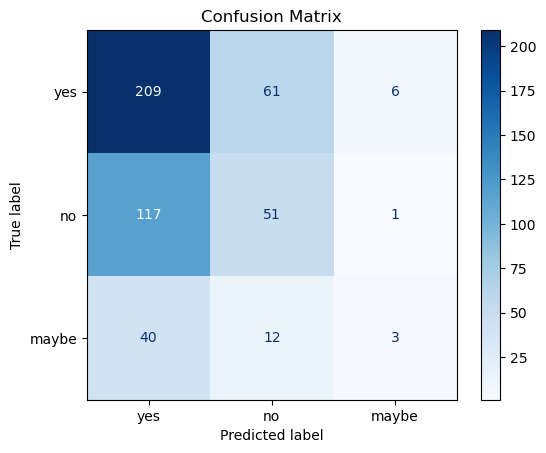

In [40]:
plot_confusion_matrix(test_labels, y_pred)

#### 6.1 error analysis

In [41]:
get_errors_by_type(data, test_labels, y_pred, true_class="maybe", pred_class="yes", n=3)

True=maybe  Predicted=yes  (total 40 errors, showing 3)
  Question: Expression of c-kit protooncogen in hepatitis B virus-induced chronic hepatitis, cirrhosis and hepatocellular carcinoma: has it a diagnostic role?
  Context: ['Paraffin-embedded tissues in Cukurova University Faculty of Medicine Department of Pathology between January 2002 and February 2006 were searched restrospectively to investigate this issue. We performed immunohistochemistry on biopsies of 125 patients with HBV infection, grouped as: mild, moderate and severe hepatitis, cirrhosis and HCC, 25 patients in each of them, using anti c-kit monoclonal antibody. The severity of parenchymal inflammation and of interface hepatitis was semiquantitatively graded on a haematoxylin and eosin stained paraffin sections. Additionally, 50 more HCC, formed on HBV basis, were studied to determine the prevalence of c-kit overexpression.', 'In cirrhotic liver, lower intensity of staining and rarely c-kit positivity were present. The g

### 7. With Dimensionality Reduction

In [42]:
grid_search_lsa = GridSearchCV(
    SVC(
        class_weight="balanced", # Handling category imbalance
        probability=True,
        random_state=RANDOM_SEED
    ),
    param_grid,
    cv=cv,
    scoring='f1_macro', # Optimization target
    n_jobs=4,           # Use 4 CPU cores
)

grid_search_lsa.fit(X_combined_lsa, combined_labels)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SVC(class_wei...ndom_state=11)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': array([ 0.1 ...100. ]), 'gamma': ['scale', 'auto'], 'kernel': ['linear', 'rbf']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",4
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter ca

In [43]:
print_grid_search_summary(grid_search_lsa)

Top 5 Hyperparameter Combinations
                                                         params  mean_test_score  std_test_score  rank_test_score
                 {'C': 100.0, 'gamma': 'auto', 'kernel': 'rbf'}         0.382899        0.032234                1
  {'C': 21.54434690031882, 'gamma': 'auto', 'kernel': 'linear'}         0.375472        0.040106                2
 {'C': 21.54434690031882, 'gamma': 'scale', 'kernel': 'linear'}         0.375472        0.040106                2
 {'C': 2.1544346900318834, 'gamma': 'auto', 'kernel': 'linear'}         0.372217        0.032363                4
{'C': 2.1544346900318834, 'gamma': 'scale', 'kernel': 'linear'}         0.372217        0.032363                4


In [44]:
print(f"Best Parameters: {grid_search_lsa.best_params_}")
print(f"Best CV Score (F1): {grid_search_lsa.best_score_:.4f}")

best_SVM_lsa = grid_search_lsa.best_estimator_

Best Parameters: {'C': np.float64(100.0), 'gamma': 'auto', 'kernel': 'rbf'}
Best CV Score (F1): 0.3829


In [45]:
y_pred_lsa = best_SVM_lsa.predict(X_test_lsa)

In [46]:
evaluate(y_pred_lsa, test_labels, "Test_set")


── Test_set ──
Accuracy: 0.4940  Macro-F1: 0.3633
              precision    recall  f1-score   support

         yes       0.57      0.68      0.62       276
          no       0.41      0.33      0.36       169
       maybe       0.13      0.09      0.11        55

    accuracy                           0.49       500
   macro avg       0.37      0.36      0.36       500
weighted avg       0.47      0.49      0.48       500



==== Error Analysis ====

True=yes (total=276, correct=187, error=89):
   Predicted no: 69/276 (25.0%)
   Predicted maybe: 20/276 (7.2%)

True=no (total=169, correct=55, error=114):
   Predicted yes: 101/169 (59.8%)
   Predicted maybe: 13/169 (7.7%)

True=maybe (total=55, correct=5, error=50):
   Predicted yes: 40/55 (72.7%)
   Predicted no: 10/55 (18.2%)


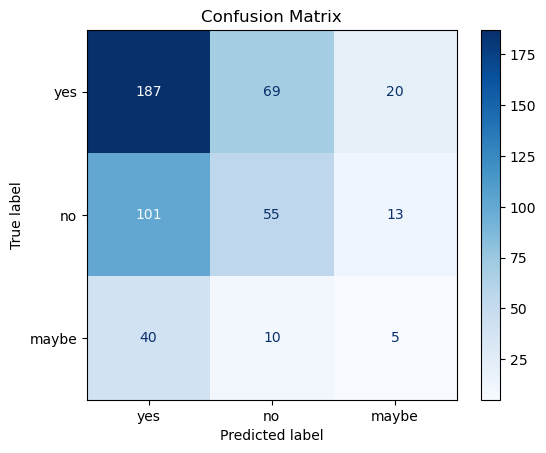

In [47]:
plot_confusion_matrix(test_labels, y_pred_lsa)